In [1]:
info_txt = r"""
likelihood:
  BAO.desi2025_all:
    python_path: /Volumes/PortableSSD/MacOS/CursoBAO/CPE/Likelihood/
    data_file: /Volumes/PortableSSD/MacOS/CursoBAO/CPE/Data/means.txt
    cov_file: /Volumes/PortableSSD/MacOS/CursoBAO/CPE/Data/covmat.txt
theory:
  classy:
    extra_args: {
    ln_A_s_1e10: 3.036,
    n_s: 0.9649,
    tau_reio: 0.0544
    }
params:
  Omega_m:
    prior:
      min: 0.1
      max: 0.9
    ref:
      dist: norm
      loc: 0.315
      scale: 0.01
    proposal: 0.01
    latex: \Omega_\mathrm{m}
  omegamh2:
    derived: 'lambda omegam, H0: omegam*(H0/100)**2'
    latex: \Omega_\mathrm{m} h^2
  H0:
    prior:
      min: 40.0
      max: 100.0
    ref:
      dist: norm
      loc: 67.36
      scale: 1.0
    proposal: 1.0
    latex: H_0
  rs_drag:
    latex: r_\mathrm{d}
  Omega_Lambda:
    latex: \Omega_\Lambda
  age:
    latex: \mathrm{Age}/\mathrm{Gyr}
  H0rdrag:
    derived: 'lambda H0, rs_drag: H0 * rs_drag'
    latex: H_0 r_\mathrm{d}
sampler:
  mcmc:
    drag: false
    oversample_power: 0.4
    proposal_scale: 1.9
    covmat: null
    Rminus1_stop: 0.01
    Rminus1_cl_stop: 0.02
    max_tries: 1000
"""

from cobaya.yaml import yaml_load

info = yaml_load(info_txt)

In [2]:
from cobaya.model import get_model

model = get_model(info)

[model] *WARNING* Ignored blocks/options: ['sampler']
[classy] `classy` module loaded successfully from /Volumes/PortableSSD/MacOS/Desilike/Mock/PS/Cobaya/code/classy/build/lib.macosx-11.0-arm64-cpython-311/classy


In [3]:
print(list(model.parameterization.sampled_params()))

['Omega_m', 'H0']


In [4]:
from cobaya import run
updated_info, sampler = run(info)

[classy] `classy` module loaded successfully from /Volumes/PortableSSD/MacOS/Desilike/Mock/PS/Cobaya/code/classy/build/lib.macosx-11.0-arm64-cpython-311/classy
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: Omega_m:0.3131519, H0:67.14005
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {BAO.desi2025_all: 3680.0, classy: 36.0}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2026-03-18 11:29:28 : 1 steps taken, and 0 accepted.
[mcmc] Learn + convergence test @ 80 samples accepted.
[mcmc]  - Acceptance rate: 0.350
[mcmc]  - Convergence of means: R-1 = 0.357161 after 64 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.355
[mcmc]  - Convergence of means: R-1 = 0.106339 af

[mcmc] *WARNING* When combining chains, it is recommended to remove some initial fraction, e.g. 'skip_samples=0.3'


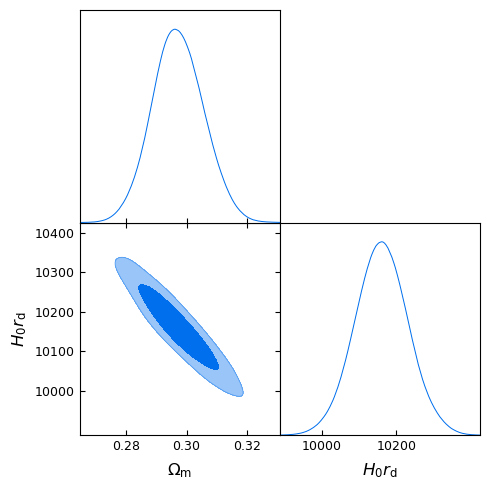

In [5]:
%matplotlib inline
import getdist.plots as gdplt

gdsamples = sampler.products(to_getdist=True)["sample"]
gdplot = gdplt.get_subplot_plotter(width_inch=5)
gdplot.triangle_plot(gdsamples, ["Omega_m", "H0rdrag"], filled=True)